# Dataset Collection and Exploratory Data Analysis (EDA)

In [134]:
# 1. Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ssl 





In [135]:
# Bypass SSL verification for macOS
ssl._create_default_https_context = ssl._create_unverified_context

# Set visualization style for professional looking plots
sns.set_theme(style="whitegrid")

# 2. Dataset Collection (Loading the data from a stable mirror)
url = "https://raw.githubusercontent.com/patilgirish815/Kidney_Cancer_Prediction_Using_Machine_Learning/main/dataset/kidney_disease.csv"


# Some datasets use '\t?' as well as '?' for missing values
df = pd.read_csv(url, na_values=['?', '\t?'])

In [136]:
df.head()  # Display the first few rows of the dataset

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [137]:
df.columns # before renaming, check the column names

Index(['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr',
       'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='str')

In [138]:
# Drop the 'id' column if it exists, as it has no clinical/predictive value
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)

# 3. Rename columns for better readability
columns_mapping = {
    'bp': 'blood_pressure', 'sg': 'specific_gravity', 'al': 'albumin', 'su': 'sugar',
    'rbc': 'red_blood_cells', 'pc': 'pus_cell', 'pcc': 'pus_cell_clumps', 'ba': 'bacteria',
    'bgr': 'blood_glucose_random', 'bu': 'blood_urea', 'sc': 'serum_creatinine', 
    'sod': 'sodium', 'pot': 'potassium', 'hemo': 'hemoglobin', 'pcv': 'packed_cell_volume',
    'wc': 'white_blood_cell_count', 'rc': 'red_blood_cell_count', 'htn': 'hypertension',
    'dm': 'diabetes_mellitus', 'cad': 'coronary_artery_disease', 'appet': 'appetite',
    'pe': 'pedal_edema', 'ane': 'anemia', 'classification': 'target' # Updated mapping
}
df.rename(columns=columns_mapping, inplace=True)
# print(df.head())

# Clean target variable (removing any invisible tabs/spaces)
df['target'] = df['target'].str.strip()
df['target'] = df['target'].map({'ckd': 1, 'notckd': 0}) 

In [139]:
df.head()  # Display the first few rows of the dataset for verification column renaming and target cleaning

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,pedal_edema,anemia,target
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,1
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,1
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,1
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,1
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,1


In [140]:
df.columns # after renaming, check the column names

Index(['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'hemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'hypertension',
       'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
       'pedal_edema', 'anemia', 'target'],
      dtype='str')

In [141]:
# 4. Basic Inspection
print("Dataset Shape:", df.shape)
print("\n--- Data Types & Missing Values ---")
print(df.info())

Dataset Shape: (400, 25)

--- Data Types & Missing Values ---
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_pressure           388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   red_blood_cells          248 non-null    str    
 6   pus_cell                 335 non-null    str    
 7   pus_cell_clumps          396 non-null    str    
 8   bacteria                 396 non-null    str    
 9   blood_glucose_random     356 non-null    float64
 10  blood_urea               381 non-null    float64
 11  serum_creatinine         383 non-null    float64
 12  sodium                   313 non-null    float64
 13  potassium                312 

In [142]:
print("Null value counts:\n", df.isnull().sum())


Null value counts:
 age                          9
blood_pressure              12
specific_gravity            47
albumin                     46
sugar                       49
red_blood_cells            152
pus_cell                    65
pus_cell_clumps              4
bacteria                     4
blood_glucose_random        44
blood_urea                  19
serum_creatinine            17
sodium                      87
potassium                   88
hemoglobin                  52
packed_cell_volume          71
white_blood_cell_count     106
red_blood_cell_count       131
hypertension                 2
diabetes_mellitus            2
coronary_artery_disease      2
appetite                     1
pedal_edema                  1
anemia                       1
target                       0
dtype: int64


In [143]:
print("Cross-tabulation of target variable:\n", df['target'].value_counts())

Cross-tabulation of target variable:
 target
1    250
0    150
Name: count, dtype: int64


/var/folders/y5/6pv_2jw54jqblm__20x22yjc0000gn/T/ipykernel_92620/948061288.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target', palette=['#2ecc71', '#e74c3c'])


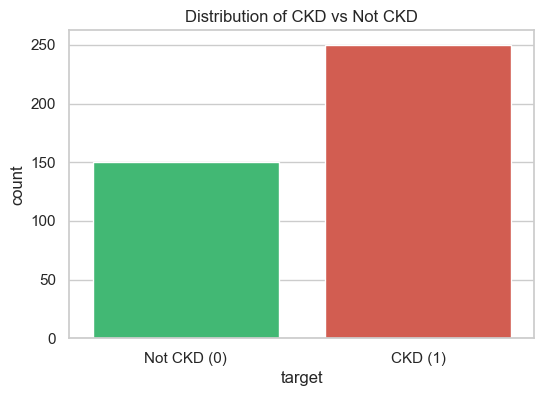

In [144]:
# 5. Visualizing the Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target', palette=['#2ecc71', '#e74c3c'])
plt.title("Distribution of CKD vs Not CKD")
plt.xticks(ticks=[0, 1], labels=['Not CKD (0)', 'CKD (1)'])
plt.show()

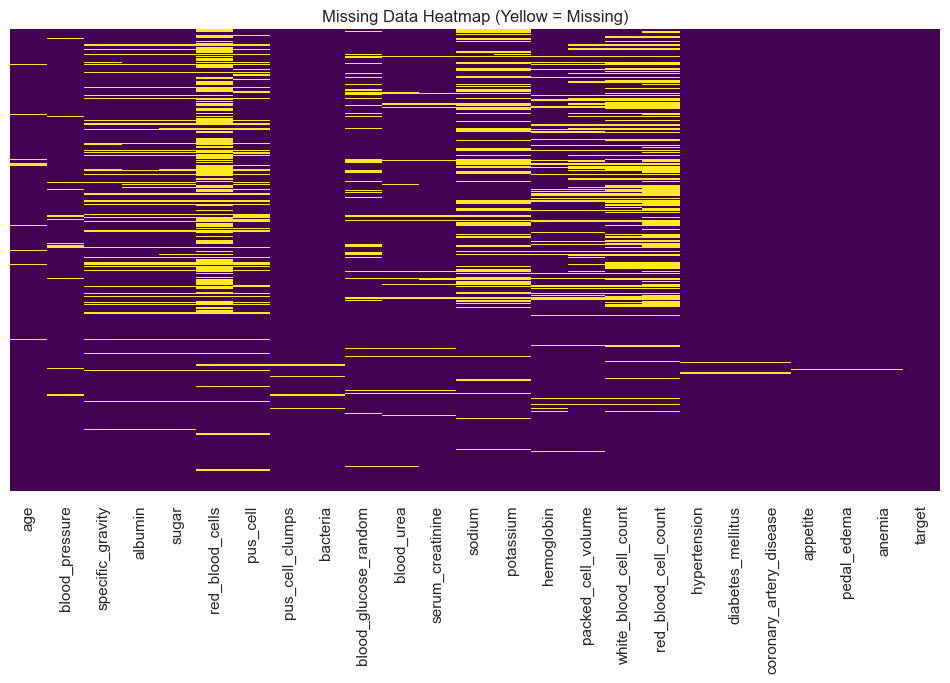

In [145]:
# 6. Visualizing Missing Data Patterns
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Missing Data Heatmap (Yellow = Missing)")
plt.show()

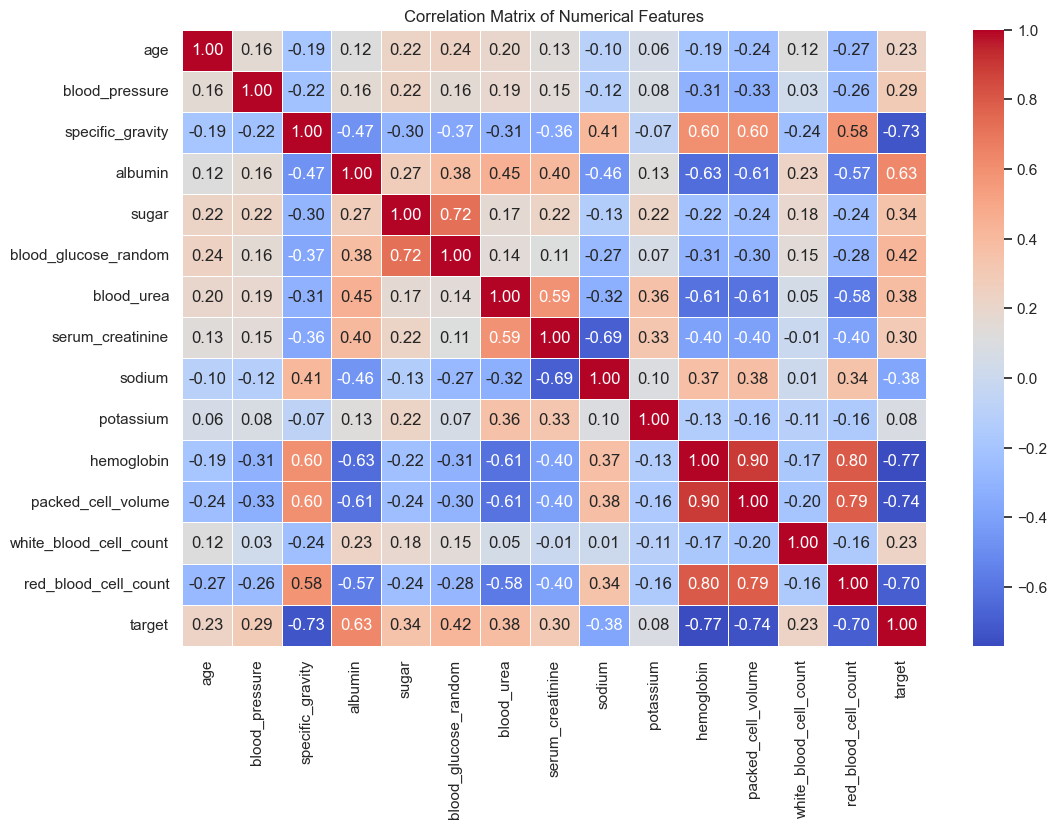

In [146]:
# 7. Correlation matrix for numerical features
plt.figure(figsize=(12, 8))
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

# Data Cleaning and Preprocessing

In [147]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder

print("Starting Data Cleaning...")

# 1. Clean invisible typos (tabs and spaces) in categorical columns
# The dataset has hidden strings like '\tyes', ' yes', or '\tno'
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    # Convert to string, strip whitespace and tabs, then replace 'nan' back to actual np.nan
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace('nan', np.nan)

Starting Data Cleaning...


/var/folders/y5/6pv_2jw54jqblm__20x22yjc0000gn/T/ipykernel_92620/3645161387.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [148]:
df.head()  # Display the first few rows of the dataset

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,pedal_edema,anemia,target
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,1
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,1
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,1
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,1
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,1


In [149]:
# 2. Fix Incorrect Data Types
# These columns are numerical but got parsed as objects due to typos in the raw file
cols_to_numeric = ['packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count']
for col in cols_to_numeric:
    # errors='coerce' forces any unreadable text (like '?') to become NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [150]:
df.age.skew()# Check skewness of numerical features to understand distribution


np.float64(-0.6682594691593559)

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'blood_pressure'}>,
        <Axes: title={'center': 'specific_gravity'}>,
        <Axes: title={'center': 'albumin'}>,
        <Axes: title={'center': 'sugar'}>],
       [<Axes: title={'center': 'blood_glucose_random'}>,
        <Axes: title={'center': 'blood_urea'}>,
        <Axes: title={'center': 'serum_creatinine'}>,
        <Axes: title={'center': 'sodium'}>,
        <Axes: title={'center': 'potassium'}>],
       [<Axes: title={'center': 'hemoglobin'}>,
        <Axes: title={'center': 'packed_cell_volume'}>,
        <Axes: title={'center': 'white_blood_cell_count'}>,
        <Axes: title={'center': 'red_blood_cell_count'}>,
        <Axes: title={'center': 'target'}>],
       [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object)

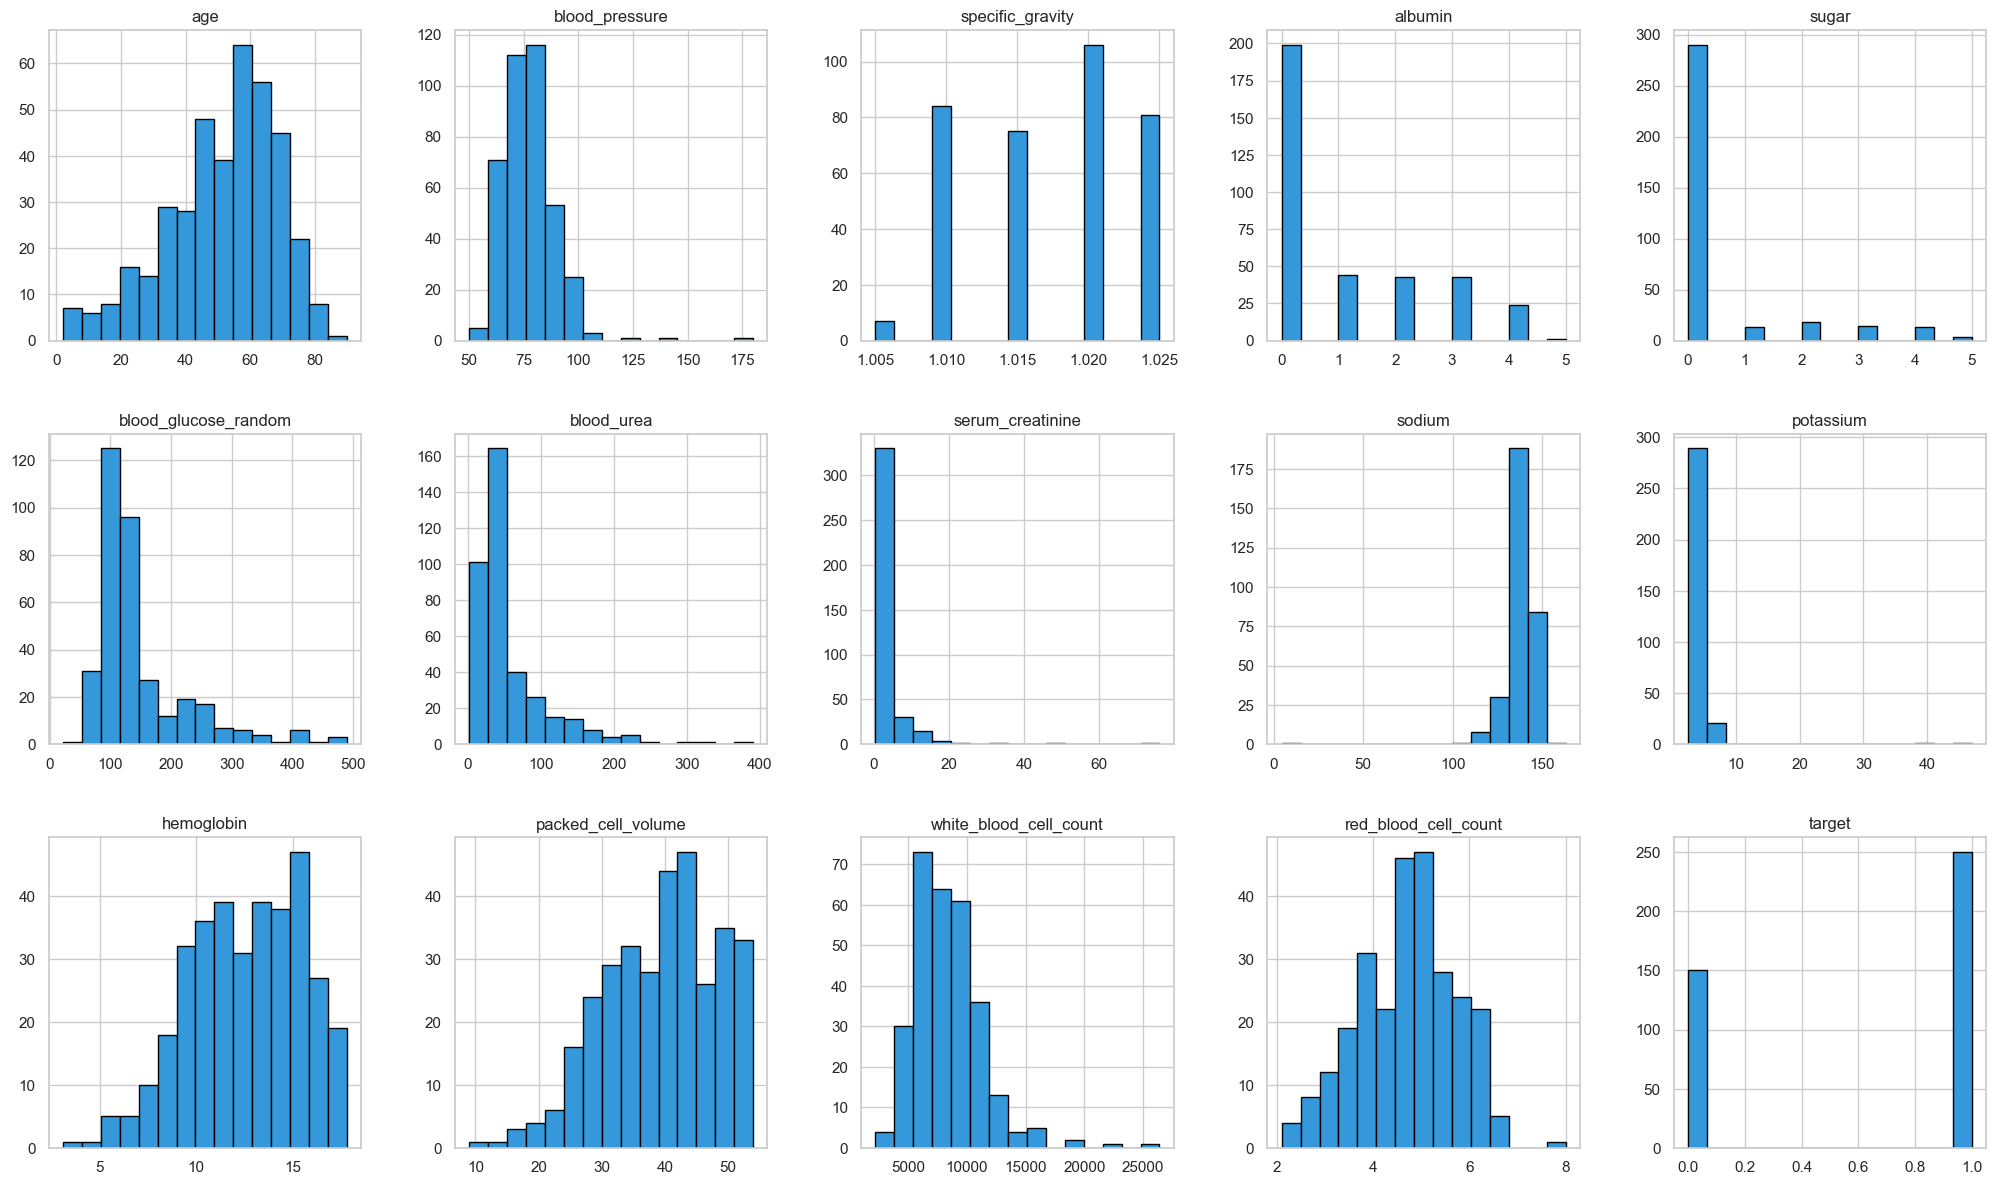

In [151]:
df.hist(bins=15, figsize=(25, 25), layout=(5, 5), color='#3498db', edgecolor='black')

In [152]:
df.head()  # Display the first few rows of the dataset before handling missing values

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,pedal_edema,anemia,target
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,1
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,1
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,1
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,1
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,1


In [153]:
# 3. Handle Missing Values (Imputation)
# Update our lists of categorical and numerical columns after the dtype fix
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Do NOT impute the target variable! Drop it from the numerical list temporarily.
if 'target' in numerical_cols:
    numerical_cols = numerical_cols.drop('target')

# A. Categorical Imputation: Fill missing with Mode (most frequent value)
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# B. Numerical Imputation: Use KNN Imputer (Research-level)
print("Applying KNN Imputation for numerical features...")
knn_imputer = KNNImputer(n_neighbors=5)
df[numerical_cols] = knn_imputer.fit_transform(df[numerical_cols])

Applying KNN Imputation for numerical features...


/var/folders/y5/6pv_2jw54jqblm__20x22yjc0000gn/T/ipykernel_92620/2723300367.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [154]:
# 4. Encode Categorical Variables (Label Encoding)
# Machine Learning models need numbers, not text like 'normal' or 'abnormal'
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le # We save the encoder for deployment later!

In [155]:
# 5. Final Sanity Check
print("\n--- Data Types After Cleaning ---")
print(df.info())
print("\n--- Total Missing Values After Cleaning ---")
print(df.isnull().sum().sum()) # Should print 0


--- Data Types After Cleaning ---
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      400 non-null    float64
 1   blood_pressure           400 non-null    float64
 2   specific_gravity         400 non-null    float64
 3   albumin                  400 non-null    float64
 4   sugar                    400 non-null    float64
 5   red_blood_cells          400 non-null    int64  
 6   pus_cell                 400 non-null    int64  
 7   pus_cell_clumps          400 non-null    int64  
 8   bacteria                 400 non-null    int64  
 9   blood_glucose_random     400 non-null    float64
 10  blood_urea               400 non-null    float64
 11  serum_creatinine         400 non-null    float64
 12  sodium                   400 non-null    float64
 13  potassium                400 non-null    float64
 14  he

In [156]:
df.describe()  # Display summary statistics of the dataset after cleaning

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,pedal_edema,anemia,target
count,400.00000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,...,400.000000,400.000000,400.000000,400.000000,400.00000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,51.31900,76.315000,1.017170,1.055000,0.464500,0.882500,0.810000,0.105000,0.055000,149.280500,...,38.933500,8466.950000,4.695250,0.367500,0.34250,0.085000,0.205000,0.190000,0.150000,0.625000
std,17.08832,13.571708,0.005481,1.287057,1.049998,0.322418,0.392792,0.306937,0.228266,76.522105,...,8.392375,2590.669338,0.898295,0.482728,0.47514,0.279231,0.404207,0.392792,0.357519,0.484729
min,2.00000,50.000000,1.005000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22.000000,...,9.000000,2200.000000,2.100000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,42.00000,70.000000,1.013000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,100.150000,...,33.000000,6900.000000,4.100000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,54.00000,80.000000,1.016000,0.300000,0.000000,1.000000,1.000000,0.000000,0.000000,122.000000,...,40.100000,8380.000000,4.770000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,64.00000,80.000000,1.020000,2.000000,0.000000,1.000000,1.000000,0.000000,0.000000,171.000000,...,45.000000,9600.000000,5.260000,1.000000,1.00000,0.000000,0.000000,0.000000,0.000000,1.000000
max,90.00000,180.000000,1.025000,5.000000,5.000000,1.000000,1.000000,1.000000,1.000000,490.000000,...,54.000000,26400.000000,8.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000


# Data Splitting, Scaling, and Feature Selection

In [157]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [158]:
print("Starting Splitting, Scaling, and Feature Selection...")

# 1. Separate Features (X) and Target (y)
X = df.drop('target', axis=1)
y = df['target']

Starting Splitting, Scaling, and Feature Selection...


In [161]:
# 2. Train-Test Split (Stratified)
# test_size=0.2 means 20% for testing, 80% for training.
# random_state=42 ensures reproducibility (you get the exact same split every time you run it)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

Training data shape: (320, 24)
Testing data shape: (80, 24)
Training target shape: (320,)
Testing target shape: (80,)


In [162]:
# 3. Feature Scaling (Preventing Data Leakage)
scaler = StandardScaler()

# FIT on the training data ONLY, then transform it
X_train_scaled = scaler.fit_transform(X_train)

# ONLY transform the test data (do NOT fit it)
X_test_scaled = scaler.transform(X_test)

# Convert NumPy arrays back to Pandas DataFrames to keep column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

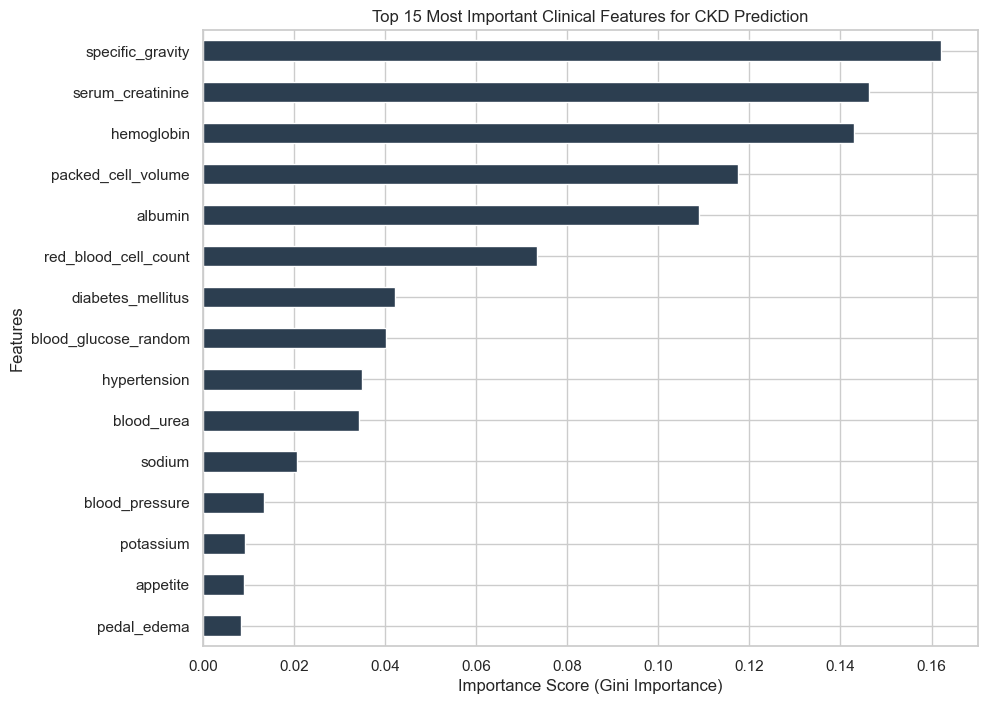

In [167]:
# 4. Feature Selection (Using Random Forest Importance)
# This model is just to calculate feature importance for our research
rf_selector = RandomForestClassifier(random_state=42, n_estimators=100)
rf_selector.fit(X_train_scaled, y_train)

# Create a DataFrame for visualization
feature_importances = pd.Series(rf_selector.feature_importances_, index=X.columns)

# Plotting the Top 15 Most Important Features
plt.figure(figsize=(10, 8))
feature_importances.nlargest(15).plot(kind='barh', color='#2c3e50')
plt.title("Top 15 Most Important Clinical Features for CKD Prediction")
plt.xlabel("Importance Score (Gini Importance)")
plt.ylabel("Features")
plt.gca().invert_yaxis() # Highest importance at the top
plt.show()